# Merge LSOA and optimise on the group

In [251]:
import os
import polars as pl
import numpy as np

from scipy.optimize import minimize
import statsmodels.api as sm  # for linear regression

import matplotlib.pyplot as plt

## Load data

Patient demographics by MSOA:

In [252]:
path_to_msoa_stats = os.path.join('data', 'msoa_cleaned.csv')

df_stats = pl.read_csv(path_to_msoa_stats)

In [253]:
df_stats.head()

MSOA,admissions,IMD2019Score,All persons,country,good_health,fair health,bad health,prop_good_health,prop_fair health,prop_bad health,MSOA11CD,age_65_proportion,age_70_proportion,age_75_proportion,age_less65_proportion,age_over80_proportion
str,f64,f64,i64,str,i64,i64,i64,f64,f64,f64,str,f64,f64,f64,f64,f64
"""Adur 001""",14.333333,16.924833,8815,"""E""",6799,1251,474,0.79763,0.146762,0.055608,"""E02006534""",0.0559,0.0528,0.0422,0.7872,0.062
"""Adur 002""",7.333333,6.4704,7263,"""E""",5537,838,259,0.83464,0.126319,0.039041,"""E02006535""",0.0578,0.0774,0.0492,0.7467,0.0692
"""Adur 003""",9.333333,13.7334,7354,"""E""",5820,969,311,0.819718,0.136479,0.043803,"""E02006536""",0.0609,0.0582,0.0421,0.7729,0.0661
"""Adur 004""",21.0,26.199857,10582,"""E""",7872,1546,709,0.777328,0.152661,0.070011,"""E02006537""",0.0465,0.0438,0.0367,0.8091,0.0638
"""Adur 005""",13.666667,11.7948,9059,"""E""",7106,1081,339,0.833451,0.126789,0.039761,"""E02006538""",0.0597,0.067,0.0425,0.7643,0.0662


Check sum of admissions for Welsh areas:

In [254]:
df_stats.filter(df_stats['country'] == 'W')['admissions'].sum()

0.0

Welsh data is always zero so remove it.

In [255]:
df_stats = df_stats.filter(df_stats['country'] != 'W')

Recalculate total numbers of patients:

In [256]:
df_stats = df_stats.with_columns((pl.col('good_health') + pl.col('fair health') + pl.col('bad health')).alias('total_health'))

In [257]:
df_stats.head()

MSOA,admissions,IMD2019Score,All persons,country,good_health,fair health,bad health,prop_good_health,prop_fair health,prop_bad health,MSOA11CD,age_65_proportion,age_70_proportion,age_75_proportion,age_less65_proportion,age_over80_proportion,total_health
str,f64,f64,i64,str,i64,i64,i64,f64,f64,f64,str,f64,f64,f64,f64,f64,i64
"""Adur 001""",14.333333,16.924833,8815,"""E""",6799,1251,474,0.79763,0.146762,0.055608,"""E02006534""",0.0559,0.0528,0.0422,0.7872,0.062,8524
"""Adur 002""",7.333333,6.4704,7263,"""E""",5537,838,259,0.83464,0.126319,0.039041,"""E02006535""",0.0578,0.0774,0.0492,0.7467,0.0692,6634
"""Adur 003""",9.333333,13.7334,7354,"""E""",5820,969,311,0.819718,0.136479,0.043803,"""E02006536""",0.0609,0.0582,0.0421,0.7729,0.0661,7100
"""Adur 004""",21.0,26.199857,10582,"""E""",7872,1546,709,0.777328,0.152661,0.070011,"""E02006537""",0.0465,0.0438,0.0367,0.8091,0.0638,10127
"""Adur 005""",13.666667,11.7948,9059,"""E""",7106,1081,339,0.833451,0.126789,0.039761,"""E02006538""",0.0597,0.067,0.0425,0.7643,0.0662,8526


Pick out column names for the health and age proportions:

In [258]:
health_numbers = ['good_health', 'fair health', 'bad health']
props_health = ['prop_good_health', 'prop_fair health', 'prop_bad health']
props_age = [
    'age_less65_proportion', 'age_65_proportion', 'age_70_proportion',
    'age_75_proportion', 'age_over80_proportion'
]

Calculate numbers of patients in each age band:

In [259]:
age_numbers = []

for col in props_age:
    new_col = col.replace('_proportion', '')
    age_numbers.append(new_col)
    df_stats = df_stats.with_columns((pl.col(col) * pl.col('total_health')).alias(new_col))

In [260]:
df_stats[['total_health'] + props_age + age_numbers].head()

total_health,age_less65_proportion,age_65_proportion,age_70_proportion,age_75_proportion,age_over80_proportion,age_less65,age_65,age_70,age_75,age_over80
i64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
8524,0.7872,0.0559,0.0528,0.0422,0.062,6710.0928,476.4916,450.0672,359.7128,528.488
6634,0.7467,0.0578,0.0774,0.0492,0.0692,4953.6078,383.4452,513.4716,326.3928,459.0728
7100,0.7729,0.0609,0.0582,0.0421,0.0661,5487.59,432.39,413.22,298.91,469.31
10127,0.8091,0.0465,0.0438,0.0367,0.0638,8193.7557,470.9055,443.5626,371.6609,646.1026
8526,0.7643,0.0597,0.067,0.0425,0.0662,6516.4218,509.0022,571.242,362.355,564.4212


## Set up bins for IMD scores

Use quantiles so that each bin contains 10% of the MSOA (to match plot notebook).

The resulting dictionary has keys for which quantile it is and values for the left side (smaller, minimum value in bin) of the IMD bin.

In [261]:
dict_quantiles = {}

for q in np.arange(0.0, 1.01, 0.2):
    v = df_stats['IMD2019Score'].quantile(q)
    # Flip the ranking because lower rank (more deprived) should be for
    # higher IMD scores (more deprived).
    q_store = 1.0 - q
    dict_quantiles[round(q_store, 1)] = round(v, 5)

In [262]:
dict_quantiles

{1.0: 2.2122,
 0.8: 10.369,
 0.6: 15.2564,
 0.4: 21.81475,
 0.2: 31.84075,
 0.0: 87.02675}

Pick out just the values for the left edges of the bins:

In [263]:
imd_bin_left_edges = {}
for k in list(dict_quantiles.keys())[:-1]:
    imd_bin_left_edges[k] = dict_quantiles[k]

In [264]:
imd_bin_left_edges

{1.0: 2.2122, 0.8: 10.369, 0.6: 15.2564, 0.4: 21.81475, 0.2: 31.84075}

Place MSOA into these bins:

In [265]:
# Make columns for the results with a placeholder value:
# df_stats = df_stats.with_columns(pl.lit(0).alias('imd_bin_min'))
# df_stats = df_stats.with_columns(pl.lit(0).alias('imd_bin_max'))
df_stats = df_stats.with_columns(pl.lit(0.0).alias('depriv_quantile_min'))
df_stats = df_stats.with_columns(pl.lit(0.0).alias('depriv_quantile_max'))

for q, quantile in enumerate(list(dict_quantiles.keys())[:-1]):
    # Pick out the bin edges:
    qmin = list(dict_quantiles.keys())[q+1]
    q0 = dict_quantiles[quantile]
    q1 = dict_quantiles[qmin]
    # Find a mask for the demographic data that contains
    # only MSOA with IMD scores in this bin.
    mask = (df_stats['IMD2019Score'] >= q0) & (df_stats['IMD2019Score'] < q1)
    if q == len(dict_quantiles) - 2:
        # Also allow values at the right edge of the final bin.
        mask = mask | (df_stats['IMD2019Score'] == q1)

    # Update the bin min/max values for these rows:
    df_stats = df_stats.with_columns(
        pl.when((mask))
        .then(qmin)         # replace with bin min
        .otherwise(pl.col('depriv_quantile_min'))  # otherwise keep the existing value
        .name.keep()
    )
    df_stats = df_stats.with_columns(
        pl.when((mask))
        .then(quantile)         # replace with bin min
        .otherwise(pl.col('depriv_quantile_max'))  # otherwise keep the existing value
        .name.keep()
    )

Check that data was binned correctly:

In [266]:
df_stats[['IMD2019Score', 'depriv_quantile_min', 'depriv_quantile_max']]

IMD2019Score,depriv_quantile_min,depriv_quantile_max
f64,f64,f64
16.924833,0.4,0.6
6.4704,0.8,1.0
13.7334,0.6,0.8
26.199857,0.2,0.4
11.7948,0.6,0.8
…,…,…
3.25925,0.8,1.0
7.29475,0.8,1.0
12.117,0.6,0.8


## Group LSOAs

In [350]:
qmin = 0.6

df_here = df_stats.filter(df_stats['depriv_quantile_min'] == qmin)

# Randomly assign groups:
groups = np.zeros(len(df_here), dtype=int)
inds_available = np.arange(len(df_here))

n_groups = 104  # 271  # 104
group_sizes = int(len(df_here)/n_groups)
group_extra = len(df_here) - ((n_groups - 1) * group_sizes)

for g in range(n_groups):
    group_size = group_sizes if g < (n_groups - 1) else group_extra
    inds = np.random.choice(inds_available, size=group_size, replace=False)
    groups[inds] = g
    inds_available = list(set(inds_available) - set(inds))

df_here = df_here.with_columns(pl.Series('group', groups))

In [351]:
print(len(df_here), group_sizes, group_extra)

1358 13 19


In [352]:
dfs_to_glob = []

cols_to_keep = ['admissions', 'All persons', 'age_less65', 'age_65', 'age_70', 'age_75', 'age_over80']

for g in range(n_groups):
    df_sum = df_here.filter(df_here['group'] == g).sum()
    # Only keep some columns:
    df_sum = df_sum[cols_to_keep]
    dfs_to_glob.append(df_sum)

df_group_sums = pl.concat(dfs_to_glob)
# Add label for group names:
df_group_sums = df_group_sums.with_columns(pl.Series('group_label', np.arange(len(df_group_sums)))) 

In [353]:
df_group_sums

admissions,All persons,age_less65,age_65,age_70,age_75,age_over80,group_label
f64,i64,f64,f64,f64,f64,f64,i64
143.333333,99664,76452.6609,5322.7051,5524.1464,4067.739,5422.0703,0
158.666667,109607,82718.6682,5770.9666,5999.6896,4418.632,5682.1932,1
137.333333,99407,73551.7542,5468.0676,5702.3604,3956.4584,5174.4765,2
136.333333,97413,72437.02,5550.9651,5779.2621,4308.8793,5918.5182,3
167.666667,110779,81856.9498,5647.9458,5854.6392,4169.27,5737.7697,4
…,…,…,…,…,…,…,…
161.0,107224,82013.7723,5248.2339,5447.6658,3931.7033,5987.3883,99
117.666667,102560,77537.6425,5315.8626,5440.0718,3985.1821,5231.7793,100
153.333333,111538,85823.1599,5672.0385,5905.3082,4066.7305,5868.9572,101


## Function for optimising

In [354]:
def main_opt(coeffs, args):
    x_lists = args[0]
    admissions = args[1]
    
    calculated_admissions = predict_admissions(x_lists, np.array(coeffs))

    # Calculate measure of difference from the observed admissions:
    # diff = find_mean_abs_diff(calculated_admissions, admissions)
    diff = find_square_residuals(calculated_admissions, admissions)
    return diff

In [355]:
def predict_admissions(x_lists, coeffs):
    """
    x_lists: np.array.
    coeffs: np.array.
    
    Have to have same number of coeffs as x_lists.
    """
    # Predicted admissions:
    yhat = (x_lists * coeffs.reshape(len(coeffs), 1)).sum(axis=0)
    return yhat

Goodness check option 1: This calculates the sum of the square of the differences between predicted and actual admission numbers:

In [356]:
def find_square_residuals(yhat, y):
    # Difference from actual:
    sqres = (yhat - y)**2.0
    # Sum of differences:
    sum_sqres = sqres.sum()
    return sum_sqres

Goodness check option 2: This calculates the mean absolute difference between the predicted and real admissions numbers:

In [357]:
def find_mean_abs_diff(yhat, y):
    # Difference from actual:
    absres = np.abs((yhat - y))
    # Mean of differences:
    mean_absres = absres.mean()
    return mean_absres

To check accuracy, the following function calculates R-squared:

In [358]:
def calculate_rsquared(y, yhat):
    """This gives the same results as the sklearn built-in."""
    y_mean = y.mean()
    ss_res = ((yhat - y)**2.0).sum()
    ss_tot = ((y - y_mean)**2.0).sum()
    if ss_tot != 0.0:
        rsq = 1.0 - ss_res / ss_tot
    else:
        rsq = np.NaN
    return rsq

## Optimise:

In [359]:
# coeffs_init = [4e-4, 5e-4, 2e-3, 6e-3, 1.7e-2]
# coeffs_init = [4e-4, 5e-4, 7e-4, 7e-4, 1.5e-2]
coeffs_init = [3e-4, 2e-3, 3e-3, 4e-3, 8e-3]

In [360]:
bounds_dict = {
    str(float(1e-4)): {'min': 7e-5, 'max': 4e-4},
    str(float(3e-4)): {'min': 9e-5, 'max': 6e-4},
    str(float(4e-4)): {'min': 1e-4, 'max': 7e-4},
    str(float(5e-4)): {'min': 2e-4, 'max': 8e-4},
    str(float(7e-4)): {'min': 4e-4, 'max': 1e-3},
    str(float(1e-3)): {'min': 7e-4, 'max': 4e-3},
    str(float(2e-3)): {'min': 8e-4, 'max': 5e-3},
    str(float(3e-3)): {'min': 9e-4, 'max': 6e-3},
    str(float(4e-3)): {'min': 1e-3, 'max': 7e-3},
    str(float(6e-3)): {'min': 3e-3, 'max': 9e-3},
    str(float(7e-3)): {'min': 4e-3, 'max': 1e-2},
    str(float(8e-3)): {'min': 5e-3, 'max': 1.1e-2},
    str(float(1e-2)): {'min': 9e-3, 'max': 2e-2},
    str(float(1.5e-2)): {'min': 9e-3, 'max': 2e-2},
    str(float(1.7e-2)): {'min': 9e-3, 'max': 2e-2},
}
bounds_dict = {
    str(float(3e-4)): {'min': 2e-4, 'max': 5e-4},
    str(float(2e-3)): {'min': 1e-3, 'max': 4e-3},
    str(float(3e-3)): {'min': 2e-3, 'max': 5e-3},
    str(float(4e-3)): {'min': 3e-3, 'max': 6e-3},
    str(float(8e-3)): {'min': 7e-3, 'max': 9e-3},
}

In [380]:
# bounds_here = [(bounds_dict[str(float(a))]['min'], bounds_dict[str(float(a))]['max']) for a in coeffs_init]
bounds_here = [(0.0, 1.0)] * len(coeffs_init)  # force results to lie between 0 and 1


# MSOA data in the same order as those coefficients:
x_lists = [df_group_sums[a] for a in age_numbers]

# Run the optimiser:
opt_results = minimize(
    main_opt,
    x0=coeffs_init,
    args=[x_lists, df_group_sums['admissions']],
    bounds=bounds_here,
    method='Nelder-Mead'
    # method='SLSQP',
)
# Pick out the resulting health coefficients:
coeffs = opt_results['x']
# Use these coefficients to predict the admissions and so
# calculate r-squared for accuracy of the fit.
admissions_predicted = predict_admissions(x_lists, coeffs)
    

In [381]:
bounds_here

[(0.0, 1.0), (0.0, 1.0), (0.0, 1.0), (0.0, 1.0), (0.0, 1.0)]

In [382]:
coeffs_init

[0.0003, 0.002, 0.003, 0.004, 0.008]

In [383]:
coeffs

array([2.33425069e-04, 8.23602292e-04, 4.47858467e-03, 7.29910136e-09,
       1.77747725e-02])

In [384]:
r2 = calculate_rsquared(df_group_sums['admissions'], admissions_predicted)
print(r2)

0.699191893590638


Check result:

In [385]:
opt_results

       message: Optimization terminated successfully.
       success: True
        status: 0
           fun: 9291.37332400118
             x: [ 2.334e-04  8.236e-04  4.479e-03  7.299e-09  1.777e-02]
           nit: 483
          nfev: 774
 final_simplex: (array([[ 2.334e-04,  8.236e-04, ...,  7.299e-09,
                         1.777e-02],
                       [ 2.334e-04,  8.279e-04, ...,  7.049e-09,
                         1.778e-02],
                       ...,
                       [ 2.335e-04,  8.242e-04, ...,  3.081e-09,
                         1.777e-02],
                       [ 2.335e-04,  8.263e-04, ...,  2.932e-09,
                         1.777e-02]]), array([ 9.291e+03,  9.291e+03,  9.291e+03,  9.291e+03,
                        9.291e+03,  9.291e+03]))

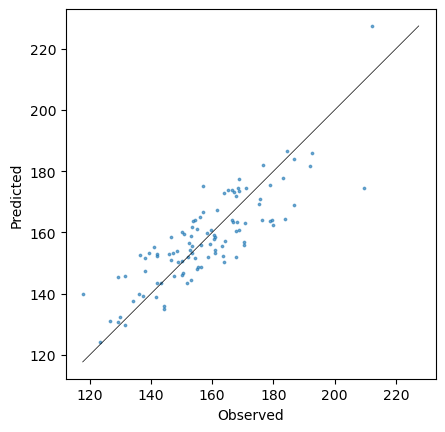

In [386]:
fig, ax = plt.subplots()
zmax = max([df_group_sums['admissions'].max(), max(admissions_predicted)])
zmin = min([df_group_sums['admissions'].min(), min(admissions_predicted)])
ax.plot([zmin, zmax], [zmin, zmax], color='k', linewidth=0.5)

ax.scatter(df_group_sums['admissions'], admissions_predicted, s=3, alpha=0.6)

ax.set_xlabel('Observed')
ax.set_ylabel('Predicted')

ax.set_aspect('equal')
plt.show()

In [387]:
with pl.Config(tbl_rows=50):
    display(pl.concat((df_group_sums['admissions'].to_frame(), pl.Series('admissions_predicted', admissions_predicted).to_frame()), how='horizontal'))

admissions,admissions_predicted
f64,f64
143.333333,143.346213
158.666667,151.931433
137.333333,139.186011
136.333333,152.563664
167.666667,151.967204
163.666667,152.331353
164.0,172.895396
154.333333,164.033989
138.0,151.529164
